In [2]:
import os 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv


# Setting a styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Connecting a database
load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connecting to PostgreSQL is success!")

Connecting to PostgreSQL is success!


C:\Users\Микаил\AppData\Local\Temp\ipykernel_97436\3498795772.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_cat, x='revenue', y='category', palette='Blues_r')


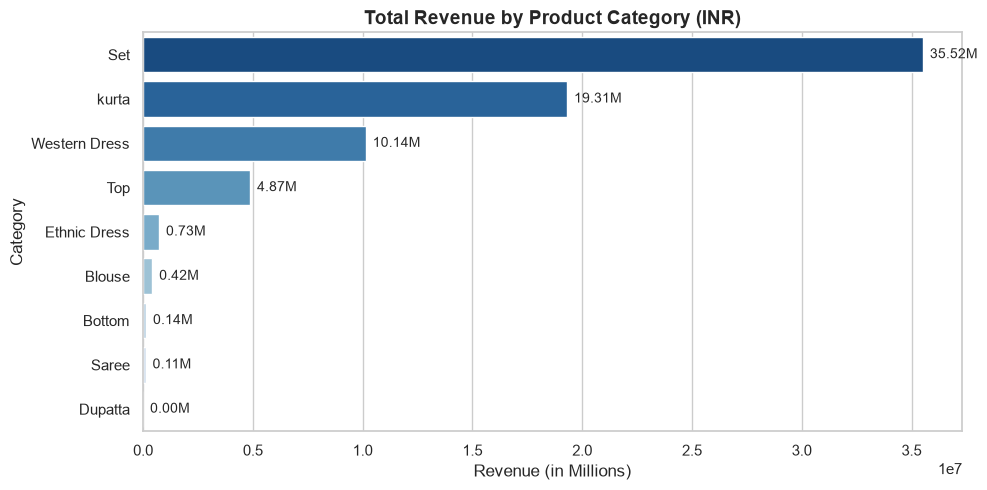

In [5]:
query_categories = """
SELECT 
    category,
    ROUND(SUM(amount)::numeric, 2) AS revenue
FROM amazon_sales
WHERE status NOT IN ('Cancelled', 'Pending') AND amount IS NOT NULL
GROUP BY category
ORDER BY revenue DESC;
"""
df_cat = pd.read_sql(query_categories, engine)

plt.figure(figsize=(10,5))
ax = sns.barplot(data=df_cat, x='revenue', y='category', palette='Blues_r')

plt.title('Total Revenue by Product Category (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (in Millions)', fontsize=12)
plt.ylabel('Category', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width/1e6:.2f}M',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.show()